In [245]:
import os, h5py, pickle
import numpy as np
import matplotlib.pyplot as plt

from main_functions_generalAPI import *
from scipy.interpolate import interp1d

recording_path = r"data\2026-02-25_mb_fish1_rec2"
save_path = r"results\2026-02-25_mb_fish1_rec2"

In [3]:
i=0
with open(os.path.join(recording_path, 'recording_dicts', f'recording_neuron{str(i)}.pkl'), 'rb') as recfile:
    recording = pickle.load(recfile)

In [4]:
list(recording.keys())

['animal_id',
 'rec_date',
 'rec_id',
 'roi_num',
 'signal_length',
 'imaging_rate',
 'ca_times',
 'record_group_ids',
 'time_resampled',
 'sample_rate',
 'display/attrs/__vxpy_status',
 'display/attrs/__vxpy_version',
 'display/CMN3D20240606Vel140Scale7Long/centers_0',
 'display/CMN3D20240606Vel140Scale7Long/indices_0',
 'display/CMN3D20240606Vel140Scale7Long/local_motion_vectors_0',
 'display/CMN3D20240606Vel140Scale7Long/motion_vectors_0',
 'display/CMN3D20240606Vel140Scale7Long/rotation_quats_0',
 'display/CMN3D20240606Vel140Scale7Long/vertices_0',
 'display/__record_group_id',
 'display/__time',
 'display/protocol0/__protocol_module',
 'display/protocol0/__protocol_name',
 'display/protocol0/__start_record_group_id',
 'display/protocol0/__start_time',
 'display/protocol0/__target_phase_count',
 'display/protocol0/__target_repeat_interval_ids',
 'positions',
 'patch_corners',
 'patch_indices',
 'cmn_phase_selection_original',
 'cmn_phase_selection',
 'cmn_motion_vectors_3d',
 'cmn_

In [16]:
camera=h5py.File(os.path.join(recording_path, 'Camera.hdf5'), 'r')

In [17]:
list(camera.keys())

['__record_group_id',
 '__time',
 'eyepos_ang_le_pos_0',
 'eyepos_ang_le_pos_0_time',
 'eyepos_ang_le_vel_0',
 'eyepos_ang_le_vel_0_time',
 'eyepos_ang_re_pos_0',
 'eyepos_ang_re_pos_0_time',
 'eyepos_ang_re_vel_0',
 'eyepos_ang_re_vel_0_time',
 'eyepos_le_axes_0',
 'eyepos_le_axes_0_time',
 'eyepos_le_saccade_0',
 'eyepos_le_saccade_0_time',
 'eyepos_le_saccade_direction_0',
 'eyepos_le_saccade_direction_0_time',
 'eyepos_re_axes_0',
 'eyepos_re_axes_0_time',
 'eyepos_re_saccade_0',
 'eyepos_re_saccade_0_time',
 'eyepos_re_saccade_direction_0',
 'eyepos_re_saccade_direction_0_time',
 'fish_embedded_frame_time']

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104], dtype=int32)

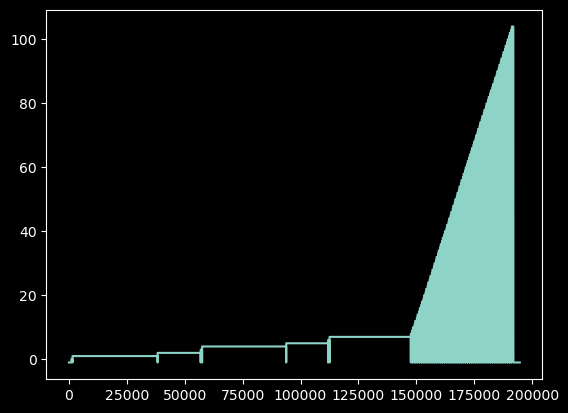

In [18]:
record_grou_id=np.array(camera['__record_group_id'])
plt.plot(record_grou_id)
np.unique(record_grou_id)

In [30]:
np.array(camera['eyepos_ang_le_pos_0']).squeeze()

array([17.32493515, 17.52360081, 17.46230979, ...,  0.04709653,
       -0.16707822,  0.11040744], shape=(166258,))

In [57]:
t1, t2=1000,4000
%matplotlib qt
plt.figure(figsize=(20,5))
plt.plot(np.array(camera['fish_embedded_frame_time']).squeeze()[t1:t2],
         np.array(camera['eyepos_ang_le_pos_0']).squeeze()[t1:t2], label='angular')
plt.plot(np.array(camera['fish_embedded_frame_time']).squeeze()[t1:t2],
         np.array(camera['eyepos_le_axes_0']).squeeze()[t1:t2]-np.array(camera['eyepos_le_axes_0']).squeeze()[t1:t2].mean(axis=0), label='absoloute')
plt.legend()

In [52]:
np.array(camera['eyepos_le_axes_0']).squeeze()[t1:t2].mean(axis=0)

array([81.3446174 , 46.07686754])

In [31]:
np.array(camera['eyepos_le_axes_0']).squeeze()

array([[84.21275352, 45.27975795],
       [84.42240434, 45.08332691],
       [84.28503215, 45.09563806],
       ...,
       [78.36882486, 45.58375758],
       [78.482701  , 45.56697845],
       [78.45365629, 45.55872369]], shape=(166258, 2))

In [19]:
np.array(camera['__time']).squeeze()

array([12340.56559634, 12340.59623885, 12340.61279416, ...,
       15663.56499195, 15663.58146739, 15663.58646774], shape=(194671,))

In [20]:
np.array(camera['fish_embedded_frame_time']).squeeze()

array([12340.56559634, 12340.59623885, 12340.61779428, ...,
       15663.54790545, 15663.56499195, 15663.58646774], shape=(166258,))

In [21]:
1/np.diff(np.array(camera['fish_embedded_frame_time']).squeeze()).mean()

np.float64(50.031885574619835)

In [22]:
time_camera=np.array(camera['__time']).squeeze()
time_camera.shape

(194671,)

In [23]:
# camera has ~60Hz
1/np.diff(time_camera).mean()

np.float64(58.58223813019148)

In [24]:
recording['ca_times']

array([12349.15830231, 12349.65857746, 12350.15885261, ...,
       15657.97815322, 15658.47842837, 15658.97870353], shape=(6617,))

In [25]:
recording['ca_times'][:1] <= time_camera[:,None]

array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]], shape=(194671, 1))

In [71]:
t1, t2=1000,2000
%matplotlib qt

left=np.array(camera['eyepos_ang_le_pos_0']).squeeze()[t1:t2]
right=np.array(camera['eyepos_ang_re_pos_0']).squeeze()[t1:t2]
time=np.array(camera['fish_embedded_frame_time']).squeeze()[t1:t2]-np.array(camera['fish_embedded_frame_time']).squeeze()[0]
time/=60

plt.figure(figsize=(20,5))
plt.plot(time,
         left, label='LEFT')
plt.plot(time,
         right, label='RIGHT')

plt.legend()

In [85]:
left_eye=np.array(camera['eyepos_ang_le_pos_0']).squeeze()
right_eye=np.array(camera['eyepos_ang_re_pos_0']).squeeze()
plt.hist(left_eye, bins=60, alpha=0.5)
plt.hist(right_eye, bins=60, alpha=0.5);

In [99]:
plt.scatter(left_eye, right_eye, s=.5, alpha=0.2)

In [207]:
time_eye=np.array(camera['fish_embedded_frame_time']).squeeze()
left_eye=np.array(camera['eyepos_ang_le_pos_0']).squeeze()
right_eye=np.array(camera['eyepos_ang_re_pos_0']).squeeze()
#eye_pos_resampled=np.empty(recording['ca_times'].shape +(2,))

# calculate average eye position within each ca time frame
# for i, (timebin_start, timebin_end) in enumerate(zip(recording['ca_times'][:-1], recording['ca_times'][1:])):
#     mask_timebin=np.where(np.logical_and(time_eye>timebin_start, time_eye<timebin_end))
#     eye_pos_resampled[i,0]=left_eye[mask_timebin].mean()
#     eye_pos_resampled[i,1]=right_eye[mask_timebin].mean()


In [209]:
time_eye.shape, left_eye.shape, right_eye.shape, eye_pos.shape

((166258,), (166258,), (166258,), (6617, 2))

In [226]:
# Define quadrants
eye_pos=np.column_stack(
    (np.array(camera['eyepos_ang_le_pos_0']).squeeze(),
     np.array(camera['eyepos_ang_re_pos_0']).squeeze()))

plt.scatter(eye_pos[:,0], eye_pos[:,1], s=1., alpha=0.6)
plt.xlabel('left')
plt.ylabel('right')

# 1st quadrant (defined by lower boundaries)
q1_min_left=10
q1_min_right=-5
width, height = 15, 28
plt.hlines((q1_min_right, q1_min_right+height),q1_min_left, q1_min_left+width)
plt.vlines((q1_min_left, q1_min_left+width),  q1_min_right, q1_min_right+height)

# 3rd quadrant (define by upper boundaries)
q3_max_left=6
q3_max_right=-12
width, height = 20, 20
plt.hlines((q3_max_right, q3_max_right-height), q3_max_left-width, q3_max_left)
plt.vlines((q3_max_left, q3_max_left-width), q3_max_right-height, q3_max_right)

In [227]:
# select data in quadrants
q1_mask=np.logical_and(eye_pos[:,0] > q1_min_left,eye_pos[:,1] > q1_min_right)
q3_mask=np.logical_and(eye_pos[:,0] < q3_max_left, eye_pos[:,1] < q3_max_right)

q1=eye_pos[q1_mask,:]
q3=eye_pos[q3_mask,:]

q1_mask.shape, q3_mask.shape

((166258,), (166258,))

In [228]:
motion_vectors_2d = recording['cmn_motion_vectors_2d']

In [231]:
Dff_all_neuron = np.load(os.path.join(save_path, "deconvolved_Dff_original.npy"))
Dff_resampled = interp1d(recording['ca_times'], Dff_all_neuron, kind='nearest')(
        recording['time_resampled'])

In [232]:
# original signal is recorded with ~2Hz
# resampled signal is upsampled and interpolated to match Display frequency for ETA calculation
Dff_all_neuron.shape, Dff_resampled.shape

((480, 6617), (480, 33099))

In [233]:
recording['ca_times'].shape

(6617,)

resample eye position signal to Display frequency first and interpolate, so we can directly select from the already upsampled Dff signal, otherwise non-continuous signal would need to be entered in the Dff calculation pipeline which is probably only for continuous time signals.

In [244]:
eye_pos_resampled = interp1d(np.array(camera['fish_embedded_frame_time']).squeeze(), eye_pos.T, kind='nearest')(recording['time_resampled'])
eye_pos_resampled.shape

(2, 33099)

In [259]:
cmn_motion_vectors_2d = recording['cmn_motion_vectors_2d']
# ROI data, timepoints mask giving calcium events during CMN stimuli phases
signal = recording['signal_selection']
cmn_phase = recording['cmn_phase_selection']  # timepoints mask giving CMN stimuli phases
sample_rate = recording['sample_rate']
radial_bin_edges = recording['radial_bin_edges']
bootstrap_num = 1000

In [ ]:
# Recording data

# calculate true ETAs based on true signal
radial_bin_norms, radial_bin_etas = calculate_local_directions(
    cmn_motion_vectors_2d[signal, :, :],
    radial_bin_edges)

recording['radial_bin_etas'] = radial_bin_etas  # ETA's
recording['radial_bin_norms'] = radial_bin_norms #

# calculate bootstrapped ETAs
frame_no=cmn_phase.sum()
min_frame_shift = 4 * sample_rate
max_frame_shift = int(frame_no - min_frame_shift)
frame_shifts = np.random.randint(min_frame_shift, max_frame_shift, size=(bootstrap_num))

radial_bin_bs_etas = np.zeros((bootstrap_num,) + radial_bin_etas.shape)
signal_within_cmn_selection = signal[cmn_phase_mask]
signal_indices = signal_within_cmn_selection.nonzero()[0][:, None]
idcs = np.mod(signal_indices + frame_shifts, signal_within_cmn_selection.size).T

# take only motion vectors during cmn stimulation
mv2d = cmn_motion_vectors_2d[cmn_phase_mask]

In [258]:
recording['radial_bin_etas'].shape

(320, 16)